In [2]:
import os
os.chdir('/home/mech/pinn-infinite-well')
print(os.getcwd())

/home/mech/pinn-infinite-well


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('outputs/summary/all_runs_noise.csv')
print(f'Total de corridas cargadas: {len(df)}')
df.groupby(['formulation','experiment'])['seed'].nunique()

Total de corridas cargadas: 7600


formulation   experiment
con_rayleigh  A1_s0         30
              A1_s0p01      30
              A1_s0p05      30
              A1_s0p1       30
sin_rayleigh  A1_s0         30
              A1_s0p01      30
              A1_s0p05      30
              A1_s0p1       30
              A2_s0          5
              A2_s0p01       5
              A2_s0p05       5
              A2_s0p1        5
Name: seed, dtype: int64

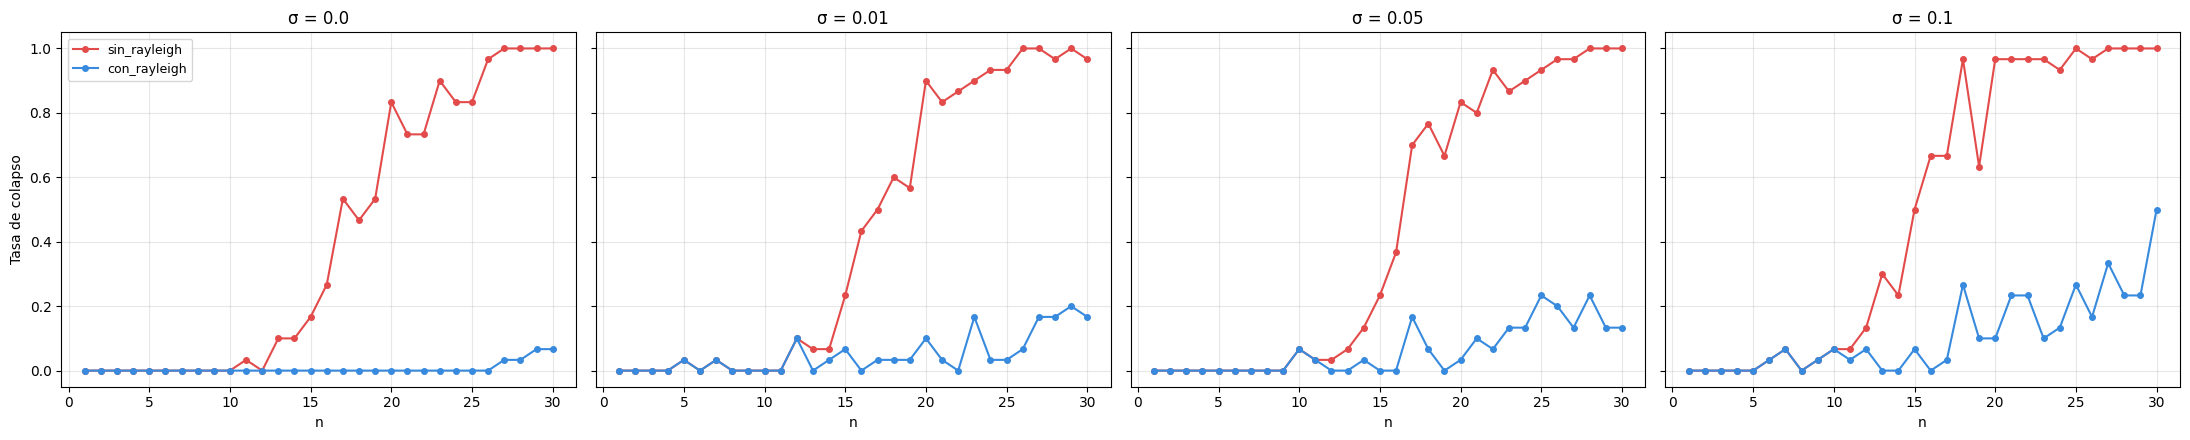

In [4]:
def sigma_from_experiment(exp_name):
    tag = exp_name.split('_')[1][1:].replace('p', '.')
    return float(tag)

def plot_collapse_rate(df, arch='A1'):
    summary = (df[df['experiment'].str.startswith(arch)]
               .groupby(['formulation','experiment','n'])
               .agg(collapse_rate=('collapse','mean'))
               .reset_index())
    summary['sigma'] = summary['experiment'].apply(sigma_from_experiment)
    sigmas = sorted(summary['sigma'].unique())
    colors = {'sin_rayleigh': '#E24B4A', 'con_rayleigh': '#378ADD'}

    fig, axes = plt.subplots(1, len(sigmas), figsize=(5.5*len(sigmas), 4.5), sharey=True)
    if len(sigmas) == 1: axes = [axes]
    for ax, sigma in zip(axes, sigmas):
        for form in ['sin_rayleigh', 'con_rayleigh']:
            sub = summary[(summary['formulation']==form) & (summary['sigma']==sigma)].sort_values('n')
            if len(sub) == 0: continue
            ax.plot(sub['n'], sub['collapse_rate'], marker='o', color=colors[form], label=form, markersize=4)
        ax.set_title(f'σ = {sigma}'); ax.set_xlabel('n'); ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3)
    axes[0].set_ylabel('Tasa de colapso'); axes[0].legend(fontsize=9)
    plt.tight_layout(); plt.show()

plot_collapse_rate(df, arch='A1')

## Falsos Positivos

In [5]:
def false_positive_summary(df, integral_thr=1e-3, E_rel_thr=1e-3):
    total_collapse = df[df['integral'] < integral_thr].copy()
    for form in ['sin_rayleigh', 'con_rayleigh']:
        sub = total_collapse[total_collapse['formulation']==form]
        n = len(sub)
        if n == 0:
            print(f'{form}: sin casos'); continue
        falsos = (sub['E_rel'] < E_rel_thr).sum()
        print(f'{form}: n={n} | E_rel mediana={sub["E_rel"].median():.4e} | '
              f'falsos positivos={falsos} ({100*falsos/n:.1f}%)')

false_positive_summary(df)

sin_rayleigh: n=1757 | E_rel mediana=4.3854e-07 | falsos positivos=1734 (98.7%)
con_rayleigh: n=173 | E_rel mediana=5.2932e-03 | falsos positivos=48 (27.7%)


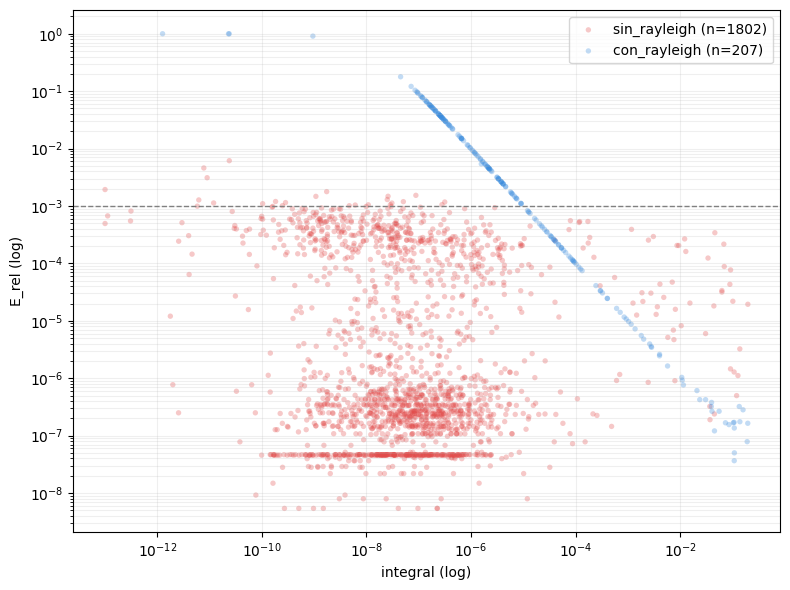

In [6]:
def plot_honesty_scatter(df):
    collapsed = df[df['collapse']==True].copy()
    eps = 1e-13
    collapsed['integral_plot'] = collapsed['integral'].clip(lower=eps)
    collapsed['E_rel_plot'] = collapsed['E_rel'].clip(lower=eps)
    colors = {'sin_rayleigh': '#E24B4A', 'con_rayleigh': '#378ADD'}

    fig, ax = plt.subplots(figsize=(8,6))
    for form in ['sin_rayleigh', 'con_rayleigh']:
        sub = collapsed[collapsed['formulation']==form]
        ax.scatter(sub['integral_plot'], sub['E_rel_plot'], s=15, alpha=0.3,
                   color=colors[form], label=f'{form} (n={len(sub)})', edgecolors='none')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('integral (log)'); ax.set_ylabel('E_rel (log)')
    ax.axhline(1e-3, color='gray', linestyle='--', linewidth=1)
    ax.legend(); ax.grid(alpha=0.2, which='both')
    plt.tight_layout(); plt.show()

plot_honesty_scatter(df)

In [7]:
def find_cases(df, formulation, integral_max=1e-3, E_rel_min=None, E_rel_max=None, n_results=10):
    sub = df[(df['formulation']==formulation) & (df['integral'] < integral_max)].copy()
    if E_rel_min is not None: sub = sub[sub['E_rel'] >= E_rel_min]
    if E_rel_max is not None: sub = sub[sub['E_rel'] <= E_rel_max]
    return sub[['experiment','seed','n','E_rel','L2','integral']].head(n_results)

find_cases(df, 'sin_rayleigh', integral_max=1e-9, E_rel_max=1e-6)

,experiment,seed,n,E_rel,L2,integral
4305,A1_s0,15,24,5.932892e-07,0.999744,3.254957e-11
4463,A1_s0,23,29,4.665517e-08,0.999732,6.687926e-10
4475,A1_s0,5,30,4.574009e-08,0.999747,2.012862e-10
4486,A1_s0,16,30,4.574009e-08,0.999749,1.870750e-10
4488,A1_s0,18,30,4.574009e-08,0.999741,3.045549e-10
5116,A1_s0p01,16,21,1.270236e-07,0.999738,1.794517e-10
5169,A1_s0p01,9,23,9.865370e-07,0.999738,6.478878e-10
5180,A1_s0p01,20,23,1.448373e-07,0.999748,3.072545e-10
5205,A1_s0p01,15,24,2.497251e-07,0.999748,2.545950e-12
5249,A1_s0p01,29,25,2.664910e-07,0.999722,8.210471e-10


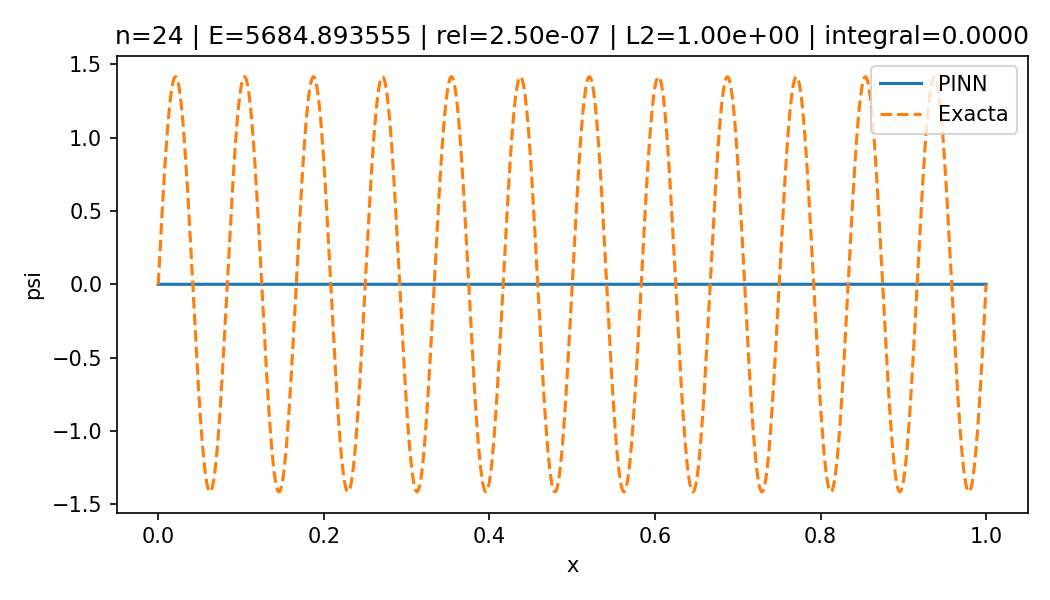

In [9]:
def case_path(formulation, experiment, seed, n, base='outputs/InfiniteWell/noise/runs'):
    return os.path.join(base, formulation, f'{experiment}_seed{seed}', f'mode_{n}')

def show_mode_image(formulation, experiment, seed, n):
    path = os.path.join(case_path(formulation, experiment, seed, n), 'mode.png')
    from IPython.display import Image, display
    display(Image(filename=path))

show_mode_image('sin_rayleigh', 'A1_s0p1', 28, 24)

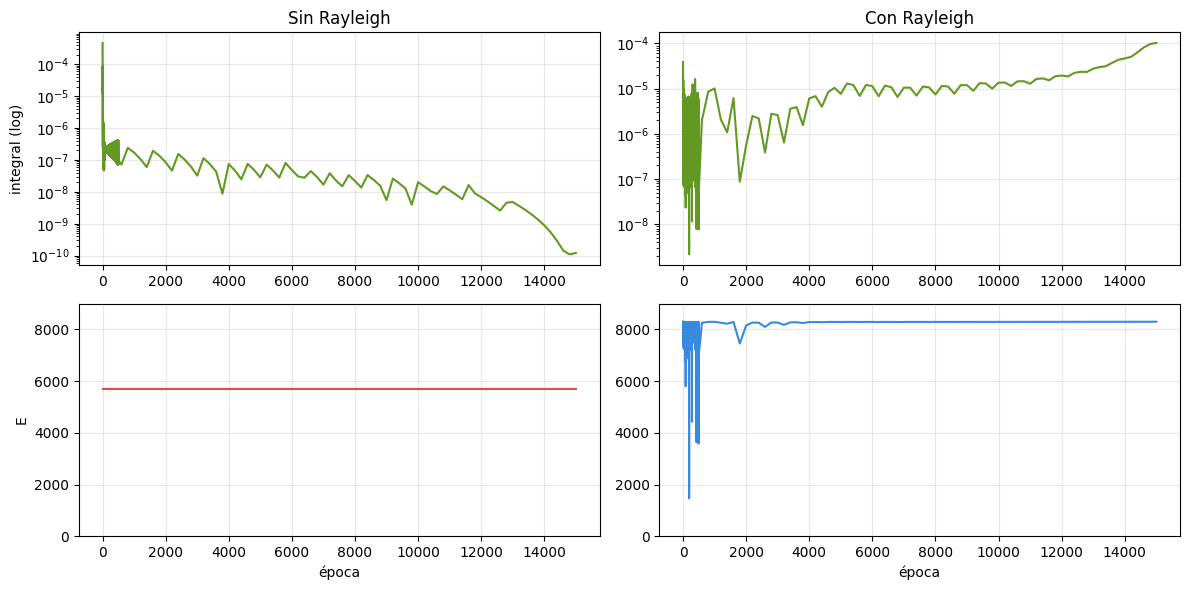

In [10]:
def load_history(formulation, experiment, seed, n):
    path = os.path.join(case_path(formulation, experiment, seed, n), 'history.npz')
    data = np.load(path)
    return data['epochs_logged'], data['E_hist'], data['int_hist']

def plot_energy_freeze_comparison(case_sin, case_con, shared_E_ylim=None):
    """case_sin y case_con son tuplas (formulation, experiment, seed, n)"""
    epochs_sin, E_sin, int_sin = load_history(*case_sin)
    epochs_con, E_con, int_con = load_history(*case_con)

    fig, axes = plt.subplots(2, 2, figsize=(12,6))
    (ax_i1, ax_i2), (ax_e1, ax_e2) = axes

    for ax_i, ax_e, epochs, E, integ, title, color in [
        (ax_i1, ax_e1, epochs_sin, E_sin, int_sin, 'Sin Rayleigh', '#E24B4A'),
        (ax_i2, ax_e2, epochs_con, E_con, int_con, 'Con Rayleigh', '#378ADD'),
    ]:
        ax_i.plot(epochs, np.clip(integ, 1e-13, None), color='#639922')
        ax_i.set_yscale('log'); ax_i.set_title(title); ax_i.grid(alpha=0.3)
        ax_e.plot(epochs, E, color=color)
        ax_e.grid(alpha=0.3)
        if shared_E_ylim: ax_e.set_ylim(*shared_E_ylim)

    ax_i1.set_ylabel('integral (log)'); ax_e1.set_ylabel('E'); ax_e1.set_xlabel('época'); ax_e2.set_xlabel('época')
    plt.tight_layout(); plt.show()

plot_energy_freeze_comparison(
    ('sin_rayleigh', 'A1_s0p1', 28, 24),
    ('con_rayleigh', 'A1_s0p1', 12, 29),
    shared_E_ylim=(0, 9000)
)

### Escalas diferentes

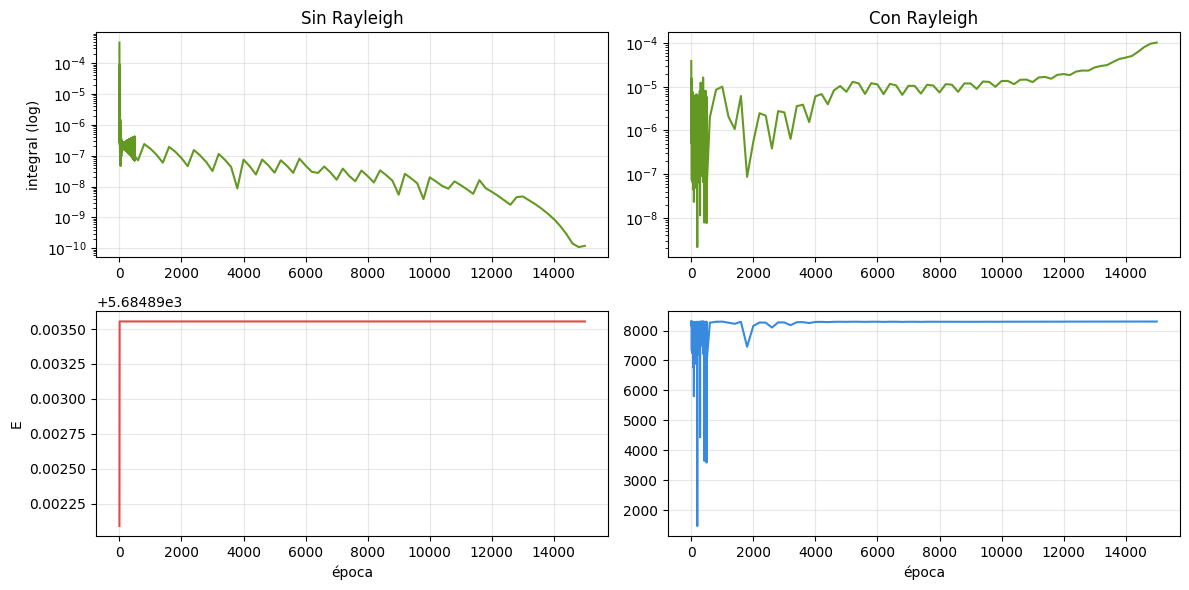

In [11]:
def load_history(formulation, experiment, seed, n):
    path = os.path.join(case_path(formulation, experiment, seed, n), 'history.npz')
    data = np.load(path)
    return data['epochs_logged'], data['E_hist'], data['int_hist']

def plot_energy_freeze_comparison(case_sin, case_con, shared_E_ylim=None):
    """case_sin y case_con son tuplas (formulation, experiment, seed, n)"""
    epochs_sin, E_sin, int_sin = load_history(*case_sin)
    epochs_con, E_con, int_con = load_history(*case_con)

    fig, axes = plt.subplots(2, 2, figsize=(12,6))
    (ax_i1, ax_i2), (ax_e1, ax_e2) = axes

    for ax_i, ax_e, epochs, E, integ, title, color in [
        (ax_i1, ax_e1, epochs_sin, E_sin, int_sin, 'Sin Rayleigh', '#E24B4A'),
        (ax_i2, ax_e2, epochs_con, E_con, int_con, 'Con Rayleigh', '#378ADD'),
    ]:
        ax_i.plot(epochs, np.clip(integ, 1e-13, None), color='#639922')
        ax_i.set_yscale('log'); ax_i.set_title(title); ax_i.grid(alpha=0.3)
        ax_e.plot(epochs, E, color=color)
        ax_e.grid(alpha=0.3)
        if shared_E_ylim: ax_e.set_ylim(*shared_E_ylim)

    ax_i1.set_ylabel('integral (log)'); ax_e1.set_ylabel('E'); ax_e1.set_xlabel('época'); ax_e2.set_xlabel('época')
    plt.tight_layout(); plt.show()

plot_energy_freeze_comparison(
    ('sin_rayleigh', 'A1_s0p1', 28, 24),
    ('con_rayleigh', 'A1_s0p1', 12, 29),
)